In [1]:
import sys
MODULEPATH="../../"
sys.path.append(MODULEPATH)
sys.path.append('../')

from connectivity.connectivity import trace_connectivity, extract_connection_indices, save_descent_paths
from connectivity.plot_results import plot_results_with_paths, plot_saddle_tree_with_function
from test_schwefel.schwefel_function_nnmodule import Schwefel2D, schwefel_loss, schwefel2D_numpy
from connectivity.connectivity import optimize_lbfgs

from connectivity.saddle_tree_calculations import saddle_tree_calculations
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
critical_points_file = "./critical_points_schwefel.csv"

dataframe = pd.read_csv(critical_points_file)
saddles_df = dataframe[dataframe["type"] == "saddle"]
minima_df = dataframe[dataframe["type"] == "minimum"]

In [3]:
all_results, minima, dataframe, paths = trace_connectivity(saddles_df,
                                                           minima_df,
                                                           dataframe,
                                                           schwefel_loss,
                                                           Schwefel2D,
                                                           [],
                                                           return_paths=True)


[0.8243749949, 0.3418094548] True 6
[0.3418094523, 0.8243749904] True 0
[0.3418094503, 0.3418094503] True 1
[0.8243749949, 0.3418094548] True 6
[0.8243749919, 0.824374992] True 3
[0.3418094523, 0.8243749904] True 0
[0.8243749919, 0.824374992] True 3
[0.0345508127, 0.8243749927] True 8
[0.3418094503, 0.3418094503] True 1
[0.0345508122, 0.3418094537] True 5
[0.3418094503, 0.0345508113] True 4


In [ ]:
save_descent_paths(paths)
extract_connection_indices(all_results, dataframe)
saddle_tree_calculations(all_results, minima, dataframe)

Saved 22 connections to results/saddle_to_minima_indices2D.csv
Saved node order to results/tree_nodes.csv
Saved tree edges to results/tree_connectivity.csv


/var/folders/87/h8fnyth55477f11hgmy38l4h0000gn/T/ipykernel_38103/3143697952.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


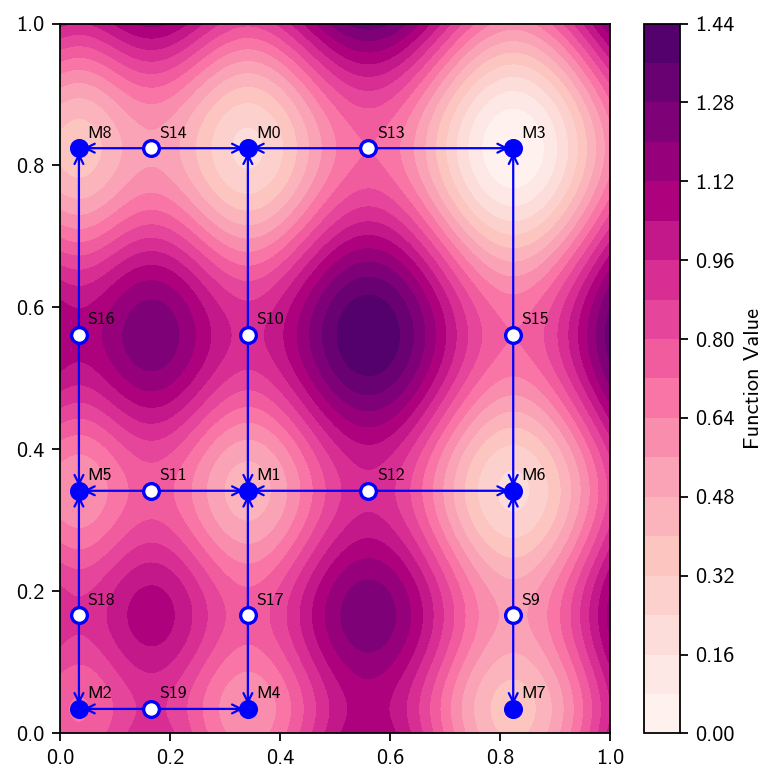

In [ ]:
fig2 = plt.figure(figsize=(5,5), dpi=160)
fig2 = plot_results_with_paths(func=schwefel2D_numpy,  
                                critical_points_csv=critical_points_file,
                                saddle_to_minima_csv="results/saddle_to_minima_indices2D.csv",      
                                bounds=(0, 1),
                                res=200,
                                fig=fig2
)
fig2.show()
fig2.savefig("plots/landscape_paths.png")  # Optional

/var/folders/87/h8fnyth55477f11hgmy38l4h0000gn/T/ipykernel_38103/545800989.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


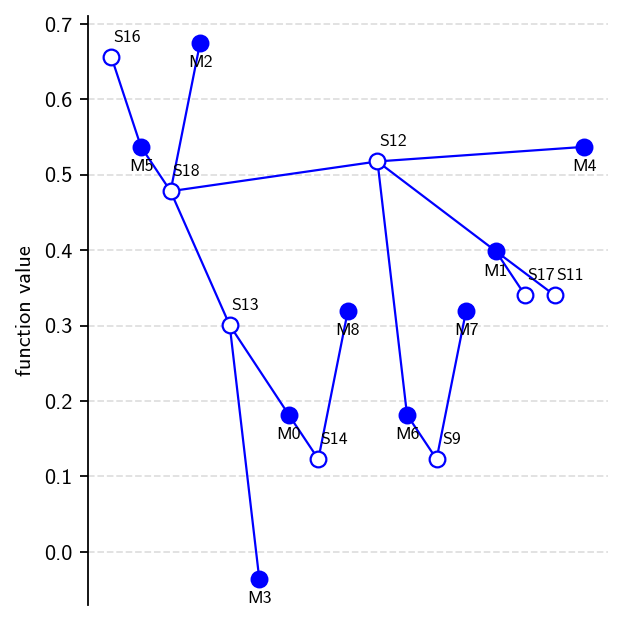

In [ ]:
fig1 = plt.figure(figsize=(4,4), dpi=160)
fig1 = plot_saddle_tree_with_function(dataframe, 
                                      nodes_csv="results/tree_nodes.csv",
                                      edges_csv="results/tree_connectivity.csv", 
                                      fig=fig1)

ax = fig1.axes[0]
ax.set_ylabel("function value")
# ax.yaxis.set_major_locator(MaxNLocator(10))
fig1.tight_layout()

fig1.show()
fig1.savefig("plots/tree_plot.png")  # Optional